# Matrizes

**Módulo:** 03 – Progressões, Matrizes e Sistemas Lineares

**Pré-requisitos:** variáveis, listas, laços e funções, vistos em [`00_introducao_python.ipynb`](../00_fundamentos_e_python/00_introducao_python.ipynb); e a noção de função, vista em [`0105a_funcoes.ipynb`](../01_conjuntos_e_funcoes/0105a_funcoes.ipynb), útil para pensar numa matriz como uma função que associa a cada par de índices (i, j) um número.

**Objetivos de aprendizagem:**
- Reconhecer os elementos de uma matriz, sua ordem m × n, e identificar as matrizes especiais mais comuns.
- Somar matrizes, multiplicar por escalar e multiplicar duas matrizes, respeitando a condição de existência de cada operação.
- Obter a transposta de uma matriz e reconhecer matrizes simétricas e antissimétricas.
- Aplicar operações elementares sobre linhas e entender intuitivamente o que é uma matriz inversível.

**Tempo estimado:** 75 a 90 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/03_progressoes_matrizes_e_sistemas_lineares/0304a_matrizes.ipynb)

📖 **Leitura complementar:** [Matriz (matemática)](https://pt.wikipedia.org/wiki/Matriz_(matem%C3%A1tica))

## A tabela do campeonato

No fim de cada rodada do campeonato, o técnico recebe uma planilha assim:

| Time | Pontos | Vitórias | Empates | Derrotas |
|---|---|---|---|---|
| Nord FC | 14 | 4 | 2 | 1 |
| Aurora United | 11 | 3 | 2 | 2 |
| Frost City | 9 | 2 | 3 | 2 |
| Snow Storm | 5 | 1 | 2 | 4 |

Repare: essa tabela é só números organizados em linhas (os times) e colunas (as estatísticas). Se eu perguntar "quantas vitórias tem o Frost City?", você olha a linha do Frost City e a coluna Vitórias, e lê o número 2 — dois índices bastam para localizar qualquer valor.

Isso é, essencialmente, uma **matriz**. E o que faz das matrizes uma ferramenta tão poderosa não é só guardar números organizados assim — é que existem operações bem definidas para *combinar* tabelas inteiras de uma vez (somar duas rodadas, multiplicar todos os valores por um fator, comparar duas tabelas) e até para *transformar* o que essas tabelas representam, como veremos quando chegarmos ao produto de matrizes.

**Pense um pouco:** se o técnico quisesse somar os pontos de duas rodadas diferentes (duas tabelas com os mesmos times e as mesmas estatísticas), o que precisaria ser verdade para que essa soma fizesse sentido linha a linha, coluna a coluna? Guarde essa pergunta — vamos formalizar isso lá na frente.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrao a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


def desenhar_matriz(
    ax,
    matriz: np.ndarray,
    titulo: str = "",
    cor_fundo: str = NORD_PAINEL,
    destaque: list[tuple[int, int]] | None = None,
    cor_destaque: str = COR_PONTO,
) -> None:
    """Desenha uma matriz como uma grade de células com os valores escritos, no estilo Nord."""
    linhas, colunas = matriz.shape
    ax.set_facecolor(NORD_FUNDO)
    destaque = destaque or []
    for i in range(linhas):
        for j in range(colunas):
            cor_celula = cor_destaque if (i, j) in destaque else cor_fundo
            ax.add_patch(
                plt.Rectangle(
                    (j, linhas - 1 - i), 1, 1,
                    facecolor=cor_celula, edgecolor=NORD_LINHA, linewidth=1.2,
                )
            )
            ax.text(
                j + 0.5, linhas - 1 - i + 0.5, f"{matriz[i, j]:g}",
                ha="center", va="center", color=NORD_TEXTO, fontsize=12,
            )
    ax.set_xlim(0, colunas)
    ax.set_ylim(0, linhas)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    ax.set_title(titulo, color=NORD_TEXTO, fontsize=11)
    for spine in ax.spines.values():
        spine.set_visible(False)


## 1. O que é uma matriz

Uma **matriz** é uma tabela retangular de números, organizada em **linhas** e **colunas**. Uma matriz com *m* linhas e *n* colunas é dita de **ordem m × n** (lê-se "m por n").

Cada número dentro da matriz é chamado de **elemento**, e é identificado por dois índices: a_ij é o elemento que está na linha *i* e na coluna *j*. A matriz inteira costuma ser representada por uma letra maiúscula:

$$A = (a_{ij})_{m \times n} = \begin{bmatrix} a_{11} & a_{12} & \cdots & a_{1n} \\ a_{21} & a_{22} & \cdots & a_{2n} \\ \vdots & \vdots & \ddots & \vdots \\ a_{m1} & a_{m2} & \cdots & a_{mn} \end{bmatrix}$$

📌 **Definição formal:** uma matriz de ordem m × n é uma tabela de m·n números reais dispostos em m linhas e n colunas. O elemento a_ij ocupa a linha i e a coluna j, com 1 ≤ i ≤ m e 1 ≤ j ≤ n.

Voltando à tabela do campeonato: ela é uma matriz de ordem 4 × 4 (4 times, 4 estatísticas). O elemento a₃₁ (linha 3, coluna 1) é o número de pontos do Frost City: 9.

In [2]:
# Tabela do campeonato como matriz: linhas = times, colunas = [pontos, vitórias, empates, derrotas]
times = ["Nord FC", "Aurora United", "Frost City", "Snow Storm"]
estatisticas = ["Pontos", "Vitorias", "Empates", "Derrotas"]

A = np.array([
    [14, 4, 2, 1],
    [11, 3, 2, 2],
    [9, 2, 3, 2],
    [5, 1, 2, 4],
])

print(f"Ordem da matriz A: {A.shape[0]} x {A.shape[1]}")
print(f"Elemento a_31 (linha 3, coluna 1): {A[2, 0]}")  # índices começam em 0 no Python

# Representação numérica: tabela com pandas
tabela_A = pd.DataFrame(A, index=times, columns=estatisticas)
tabela_A

Ordem da matriz A: 4 x 4
Elemento a_31 (linha 3, coluna 1): 9


,Pontos,Vitorias,Empates,Derrotas
Nord FC,14,4,2,1
Aurora United,11,3,2,2
Frost City,9,2,3,2
Snow Storm,5,1,2,4


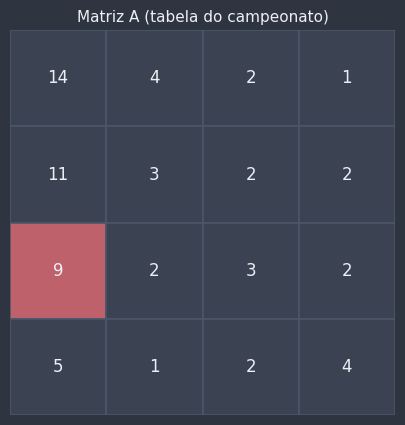

In [3]:
fig, ax = plt.subplots(figsize=(5.5, 5))
fig.patch.set_facecolor(NORD_FUNDO)
desenhar_matriz(ax, A, titulo="Matriz A (tabela do campeonato)", destaque=[(2, 0)], cor_destaque=COR_ALERTA)
plt.show()

**Pergunta de checagem:** no código Python, `A[2, 0]` acessa o elemento a₃₁ da matriz (linha 3, coluna 1). Por que o índice usado foi `2` e não `3`?

## 2. Matrizes especiais

Algumas formas de matriz aparecem tanto que ganham nome próprio:

- **Matriz linha**: tem uma única linha (ordem 1 × n).
- **Matriz coluna**: tem uma única coluna (ordem m × 1).
- **Matriz quadrada**: o número de linhas é igual ao número de colunas (ordem n × n).
- **Matriz nula**: todos os elementos são zero.
- **Matriz diagonal**: quadrada, com todos os elementos fora da diagonal principal iguais a zero (os da diagonal podem ser quaisquer números).
- **Matriz identidade**: diagonal, com todos os elementos da diagonal principal iguais a 1. É representada por I (ou Iₙ, para deixar a ordem explícita).

A **diagonal principal** de uma matriz quadrada é o conjunto dos elementos a_ii (linha = coluna): a₁₁, a₂₂, ..., aₙₙ.

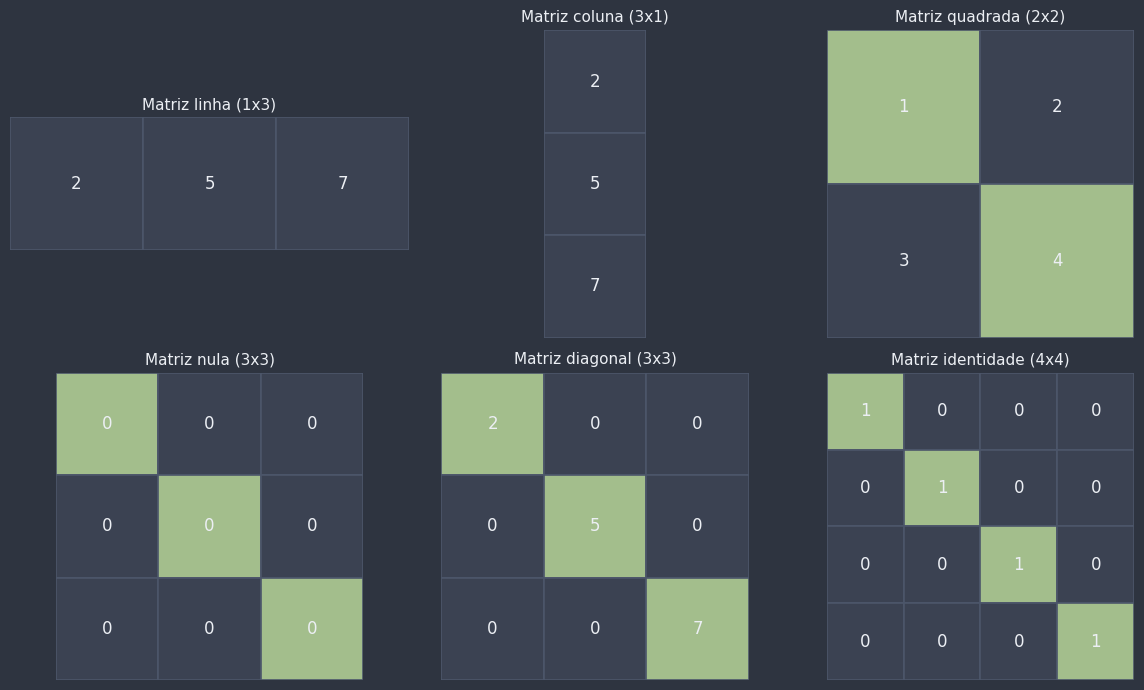

In [4]:
matriz_linha = np.array([[2, 5, 7]])
matriz_coluna = np.array([[2], [5], [7]])
matriz_quadrada = np.array([[1, 2], [3, 4]])
matriz_nula = np.zeros((3, 3), dtype=int)
matriz_diagonal = np.diag([2, 5, 7])
matriz_identidade = np.eye(4, dtype=int)

fig, eixos = plt.subplots(2, 3, figsize=(12, 7))
fig.patch.set_facecolor(NORD_FUNDO)

matrizes_especiais = [
    (matriz_linha, "Matriz linha (1x3)"),
    (matriz_coluna, "Matriz coluna (3x1)"),
    (matriz_quadrada, "Matriz quadrada (2x2)"),
    (matriz_nula, "Matriz nula (3x3)"),
    (matriz_diagonal, "Matriz diagonal (3x3)"),
    (matriz_identidade, "Matriz identidade (4x4)"),
]

for ax, (matriz, titulo) in zip(eixos.flat, matrizes_especiais):
    eh_quadrada = matriz.shape[0] == matriz.shape[1]
    diagonal = [(i, i) for i in range(min(matriz.shape))] if eh_quadrada else []
    desenhar_matriz(ax, matriz, titulo=titulo, destaque=diagonal, cor_destaque=COR_DESTAQUE)

plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** arraste o slider para mudar a ordem n e ver a matriz identidade Iₙ correspondente.

In [5]:
def mostrar_identidade(n: int) -> None:
    matriz_I = np.eye(n, dtype=int)
    fig, ax = plt.subplots(figsize=(1.2 * n + 1, 1.2 * n + 1))
    fig.patch.set_facecolor(NORD_FUNDO)
    desenhar_matriz(
        ax, matriz_I, titulo=f"Identidade I_{n} ({n}x{n})",
        destaque=[(i, i) for i in range(n)], cor_destaque=COR_DESTAQUE,
    )
    plt.show()


widgets.interact(mostrar_identidade, n=widgets.IntSlider(value=3, min=1, max=8, step=1, description="n:"))

interactive(children=(IntSlider(value=3, description='n:', max=8, min=1), Output()), _dom_classes=('widget-int…

<function __main__.mostrar_identidade(n: int) -> None>

💡 **Dica:** guarde essa intuição — a matriz identidade vai funcionar como o "1" da multiplicação de matrizes: multiplicar qualquer matriz A pela identidade (na ordem certa) devolve a própria A, sem mudar nada. Vamos confirmar isso lá no Bloco 7.

**Pergunta de checagem:** toda matriz diagonal é uma matriz identidade? E toda matriz identidade é uma matriz diagonal? Explique a diferença.

## 3. Matriz simétrica e antissimétrica

Essas duas classificações só existem para **matrizes quadradas**, e comparam a matriz com sua transposta Aᵀ (a transposta será formalizada no Bloco 8 — por ora, basta saber que "transpor" significa trocar linhas por colunas).

- **Matriz simétrica**: A = Aᵀ. Visualmente, os elementos são "espelhados" em relação à diagonal principal: a_ij = a_ji para todo i, j.
- **Matriz antissimétrica**: A = −Aᵀ. Isso força a_ij = −a_ji, e em particular a_ii = −a_ii, ou seja, **todo elemento da diagonal principal é zero**.

⚠️ **Erro comum:** só faz sentido perguntar se uma matriz é simétrica ou antissimétrica quando ela é quadrada — matrizes retangulares nem entram nessa classificação, porque Aᵀ teria ordem diferente de A e a comparação não faria sentido.

In [29]:
# Matriz de distâncias entre 4 cidades (em km, aproximado) - simétrica por natureza
cidades = ["SP", "RJ", "BH", "Curitiba"]
distancias = np.array([
    [0, 430, 490, 410],
    [430, 0, 440, 850],
    [490, 440, 0, 1000],
    [410, 850, 1000, 0],
])

eh_simetrica = np.array_equal(distancias, distancias.T)
print(f"Matriz de distancias é simétrica? {eh_simetrica}")

# Matriz de diferenças de temperatura entre pares de cidades - antissimétrica por construção
temperaturas = np.array([24, 28, 22, 18])  # SP, RJ, BH, Curitiba
diferencas = temperaturas[np.newaxis, :] - temperaturas[:, np.newaxis]

eh_antissimetrica = np.array_equal(diferencas, -diferencas.T)
print(f"Matriz de diferencas de temperatura é antissimetrica? {eh_antissimetrica}")
print(f"Diagonal principal (deveria ser toda zero): {np.diag(diferencas)}")

Matriz de distancias é simétrica? True
Matriz de diferencas de temperatura é antissimetrica? True
Diagonal principal (deveria ser toda zero): [0 0 0 0]


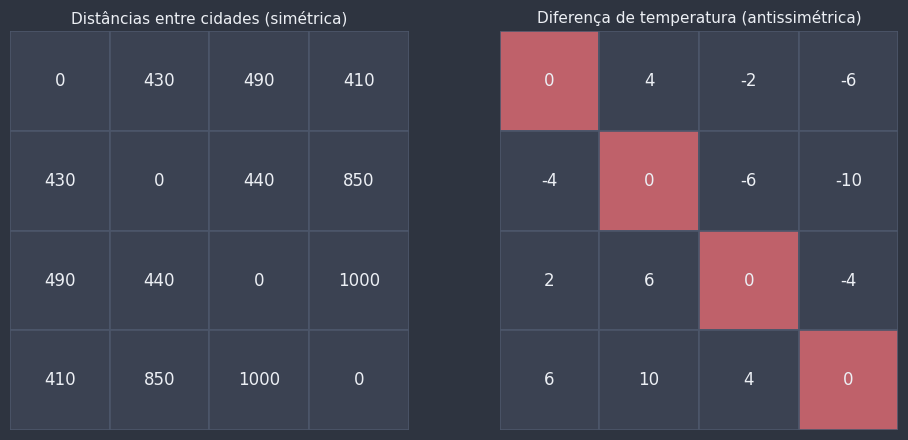

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
desenhar_matriz(ax1, distancias, titulo="Distâncias entre cidades (simétrica)")
desenhar_matriz(
    ax2, diferencas, titulo="Diferença de temperatura (antissimétrica)",
    destaque=[(i, i) for i in range(4)], cor_destaque=COR_ALERTA,
)
plt.tight_layout()
plt.show()

🎯 **Aplicação prática:** matrizes de distância (entre cidades, entre pontos de uma rede, entre objetos num algoritmo de agrupamento) são sempre simétricas, porque a distância de A até B é igual à distância de B até A. Já matrizes que registram uma "diferença direcionada" (temperatura de um lugar menos a de outro, saldo de um time contra outro) costumam ser antissimétricas.

**Pergunta de checagem:** por que a diagonal principal de qualquer matriz antissimétrica é sempre nula? (Dica: o que a_ii = −a_ii força a_ii a valer?)

## 4. Igualdade de matrizes

Duas matrizes A e B são **iguais** quando:

1. Têm a mesma ordem (mesmo número de linhas e mesmo número de colunas), e
2. Todos os elementos correspondentes são iguais: a_ij = b_ij para todo i, j.

⚠️ **Erro comum:** ter os "mesmos números" não basta. Uma matriz 2×2 com os números 1, 2, 3, 4 dispostos numa ordem não é igual a outra matriz com os mesmos quatro números dispostos de outro jeito — e nem sequer é igual a uma matriz de ordem diferente com os mesmos números.

In [30]:
B = np.array([[1, 2], [3, 4]])
C = np.array([[1, 2], [3, 4]])
D = np.array([[1, 3], [2, 4]])  # mesmos números, dispostos diferente
E = np.array([[1, 2, 3], [4, 0, 0]])  # ordem (2x3) diferente de B

print(f"B == C, com os mesmos elementos nas mesmas posições: {np.array_equal(B, C)}")
print(f"B == D, mesmos números mas dispostos diferente: {np.array_equal(B, D)}")
print(f"B tem a mesma ordem de E? {B.shape == E.shape}")

B == C, com os mesmos elementos nas mesmas posições: True
B == D, mesmos números mas dispostos diferente: False
B tem a mesma ordem de E? False


**Pergunta de checagem:** duas matrizes nulas, uma de ordem 2×3 e outra de ordem 3×2, têm exatamente os mesmos elementos (todos zero). Elas são iguais? Por quê?

## 5. Adição de matrizes

A soma A + B é definida **elemento a elemento**: (A + B)_ij = a_ij + b_ij. Por isso, só é possível somar matrizes de **mesma ordem** — não dá pra somar, elemento a elemento, uma linha que nem existe na outra matriz.

A soma de matrizes tem as mesmas propriedades "de sempre": é comutativa (A + B = B + A) e associativa ((A + B) + C = A + (B + C)).

In [31]:
# Vendas de duas lojas (linhas) em dois produtos (colunas), em dois meses diferentes
vendas_marco = np.array([[120, 80], [95, 60]])
vendas_abril = np.array([[110, 95], [100, 70]])

vendas_bimestre = vendas_marco + vendas_abril
print("Vendas acumuladas (marco + abril):")
print(vendas_bimestre)

Vendas acumuladas (marco + abril):
[[230 175]
 [195 130]]


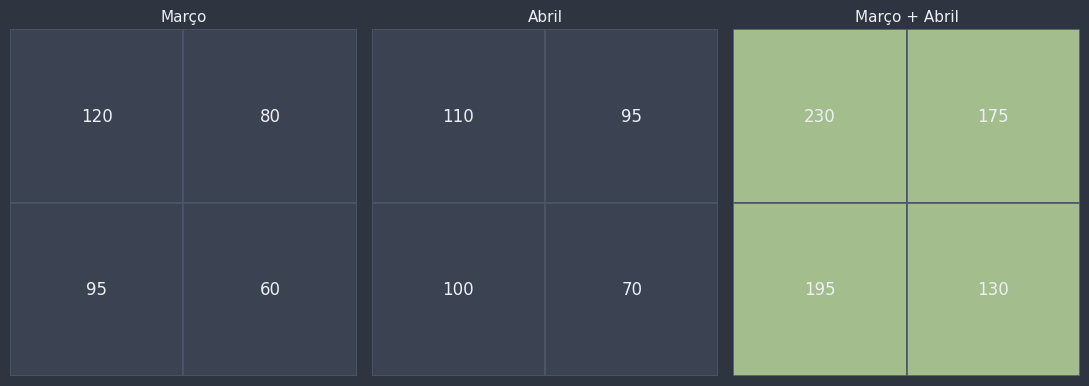

In [32]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 4))
fig.patch.set_facecolor(NORD_FUNDO)
desenhar_matriz(ax1, vendas_marco, titulo="Março")
desenhar_matriz(ax2, vendas_abril, titulo="Abril")
desenhar_matriz(
    ax3, vendas_bimestre, titulo="Março + Abril",
    destaque=[(i, j) for i in range(2) for j in range(2)], cor_destaque=COR_DESTAQUE,
)
plt.tight_layout()
plt.show()

🎯 **Aplicação prática:** somar duas planilhas de vendas (mesmas lojas, mesmos produtos) de meses diferentes é o exemplo clássico de adição de matrizes — cada célula do resultado é o total acumulado daquela loja naquele produto.

**Pergunta de checagem:** se a loja 2 tivesse vendido um terceiro produto em abril (uma coluna a mais), ainda seria possível somar `vendas_marco + vendas_abril` como está? O que precisaria mudar?

## 6. Produto de número por matriz

Multiplicar uma matriz A por um número real k (chamado **escalar**) significa multiplicar **cada elemento** de A por k: (k·A)_ij = k · a_ij. O resultado tem a mesma ordem de A.

In [33]:
precos = np.array([[19.90, 34.50], [12.00, 27.80]])  # linhas: produtos, colunas: [custo, venda]
precos_dobrados = 2 * precos

print("Preços originais:")
print(precos)
print("Preços apos reajuste de 100% (multiplicar por 2):")
print(precos_dobrados)

Preços originais:
[[19.9 34.5]
 [12.  27.8]]
Preços apos reajuste de 100% (multiplicar por 2):
[[39.8 69. ]
 [24.  55.6]]


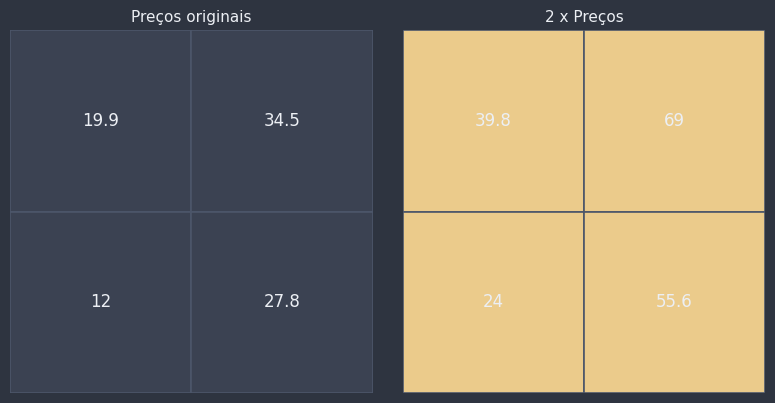

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
fig.patch.set_facecolor(NORD_FUNDO)
desenhar_matriz(ax1, precos, titulo="Preços originais")
desenhar_matriz(
    ax2, precos_dobrados, titulo="2 x Preços",
    destaque=[(i, j) for i in range(2) for j in range(2)], cor_destaque=COR_AVISO,
)
plt.tight_layout()
plt.show()

**Pergunta de checagem:** o que acontece com uma matriz identidade Iₙ quando ela é multiplicada por um escalar k? O resultado ainda é uma matriz identidade? Que nome você daria a essa nova matriz (diagonal, com todos os elementos da diagonal iguais a k)?

## 7. Produto de matrizes

O produto de matrizes é bem menos intuitivo que a soma. Primeiro, a condição de existência: o produto A·B só existe se o **número de colunas de A** for igual ao **número de linhas de B**. Se A tem ordem m × p e B tem ordem p × n, o resultado A·B tem ordem m × n.

Cada elemento do resultado é calculado "linha de A vezes coluna de B":

$$(A \cdot B)_{ij} = \sum_{k=1}^{p} a_{ik} \cdot b_{kj}$$

Ou seja: para achar o elemento na linha i, coluna j do resultado, você pega a linha i inteira de A, a coluna j inteira de B, multiplica os elementos correspondentes e soma tudo.

In [13]:
A = np.array([[1, 2, 3], [4, 5, 6]])  # ordem 2x3
B = np.array([[7, 8], [9, 10], [11, 12]])  # ordem 3x2

print(f"A tem ordem {A.shape}, B tem ordem {B.shape}")
print(f"Colunas de A ({A.shape[1]}) == linhas de B ({B.shape[0]})? {A.shape[1] == B.shape[0]}")

produto = A @ B
print(f"A @ B tem ordem {produto.shape}:")
print(produto)

# Conferindo na mao o elemento (0, 0) do resultado: linha 0 de A vezes coluna 0 de B
elemento_00 = A[0, 0] * B[0, 0] + A[0, 1] * B[1, 0] + A[0, 2] * B[2, 0]
print(f"Elemento (0,0) calculado na mao: {elemento_00}, e via numpy: {produto[0, 0]}")

A tem ordem (2, 3), B tem ordem (3, 2)
Colunas de A (3) == linhas de B (3)? True
A @ B tem ordem (2, 2):
[[ 58  64]
 [139 154]]
Elemento (0,0) calculado na mao: 58, e via numpy: 58


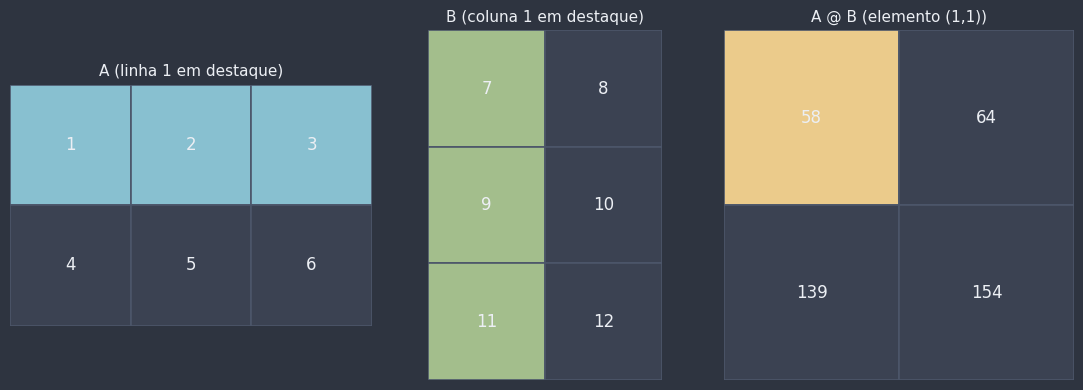

In [14]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 4))
fig.patch.set_facecolor(NORD_FUNDO)
desenhar_matriz(ax1, A, titulo="A (linha 1 em destaque)", destaque=[(0, j) for j in range(3)], cor_destaque=COR_PONTO)
desenhar_matriz(ax2, B, titulo="B (coluna 1 em destaque)", destaque=[(i, 0) for i in range(3)], cor_destaque=COR_DESTAQUE)
desenhar_matriz(ax3, produto, titulo="A @ B (elemento (1,1))", destaque=[(0, 0)], cor_destaque=COR_AVISO)
plt.tight_layout()
plt.show()

⚠️ **Erro comum:** o produto de matrizes **não é comutativo**: em geral, A·B ≠ B·A. Isso vale mesmo quando os dois produtos existem (o que só acontece se A e B forem quadradas de mesma ordem, ou em outros casos especiais de ordens compatíveis nos dois sentidos).

In [15]:
M1 = np.array([[1, 2], [0, 1]])
M2 = np.array([[3, 0], [1, 1]])

print("M1 @ M2:")
print(M1 @ M2)
print("M2 @ M1:")
print(M2 @ M1)
print(f"M1 @ M2 == M2 @ M1? {np.array_equal(M1 @ M2, M2 @ M1)}")

M1 @ M2:
[[5 2]
 [1 1]]
M2 @ M1:
[[3 6]
 [1 3]]
M1 @ M2 == M2 @ M1? False


🕹️ **Widget interativo:** mexa nos sliders de ordem de A e de B e veja se o produto A·B existe, e qual seria a ordem do resultado.

In [35]:
def checar_produto(linhas_a: int, colunas_a: int, linhas_b: int, colunas_b: int) -> None:
    print(f"A: {linhas_a} x {colunas_a}     B: {linhas_b} x {colunas_b}")
    if colunas_a == linhas_b:
        print(f"Produto A @ B existe! Ordem do resultado: {linhas_a} x {colunas_b}")
    else:
        print(f"Produto A @ B NÃO existe: colunas de A ({colunas_a}) != linhas de B ({linhas_b})")


widgets.interact(
    checar_produto,
    linhas_a=widgets.IntSlider(value=2, min=1, max=5, description="linhas A:"),
    colunas_a=widgets.IntSlider(value=3, min=1, max=5, description="colunas A:"),
    linhas_b=widgets.IntSlider(value=3, min=1, max=5, description="linhas B:"),
    colunas_b=widgets.IntSlider(value=2, min=1, max=5, description="colunas B:"),
)

interactive(children=(IntSlider(value=2, description='linhas A:', max=5, min=1), IntSlider(value=3, descriptio…

<function __main__.checar_produto(linhas_a: int, colunas_a: int, linhas_b: int, colunas_b: int) -> None>

Confirmando a intuição do Bloco 2: a identidade realmente se comporta como o "1" da multiplicação.

In [17]:
matriz_I = np.eye(3, dtype=int)
N = np.array([[2, 5, 1], [0, 3, 4], [7, 1, 6]])
print(f"N @ I == N? {np.array_equal(N @ matriz_I, N)}")
print(f"I @ N == N? {np.array_equal(matriz_I @ N, N)}")

N @ I == N? True
I @ N == N? True


🎯 **Aplicação prática — transformações geométricas:** multiplicar um conjunto de pontos (organizados como colunas de uma matriz) por uma **matriz de rotação** gira esses pontos no plano. É assim que jogos e softwares gráficos giram, escalam e movem objetos na tela — tudo via produto de matrizes.

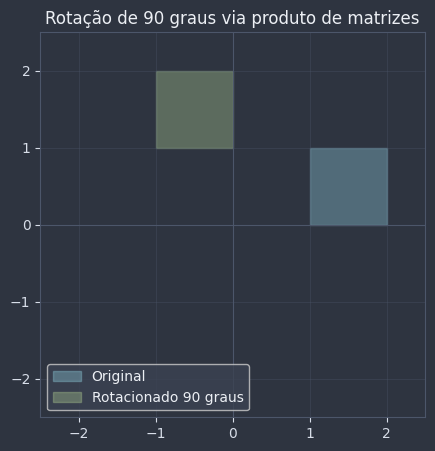

In [36]:
angulo = np.radians(90)
rotacao_90 = np.array([[np.cos(angulo), -np.sin(angulo)], [np.sin(angulo), np.cos(angulo)]])

pontos = np.array([[1, 0], [2, 0], [2, 1], [1, 1]]).T  # um "quadrado", pontos como colunas
pontos_rotacionados = rotacao_90 @ pontos

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.fill(*pontos, color=COR_PONTO, alpha=0.4, label="Original")
ax.fill(*pontos_rotacionados, color=COR_DESTAQUE, alpha=0.4, label="Rotacionado 90 graus")
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect("equal")
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO)
ax.set_title("Rotação de 90 graus via produto de matrizes", color=NORD_TEXTO)
plt.show()

📖 **Leitura complementar:** [Multiplicação de matrizes](https://pt.wikipedia.org/wiki/Multiplica%C3%A7%C3%A3o_de_matrizes) — verbete em português, com mais detalhes sobre propriedades e complexidade.

**Pergunta de checagem:** se A tem ordem 3×2 e B tem ordem 2×5, o produto A·B existe? E o produto B·A? Justifique usando a condição de existência.

## 8. Matriz transposta

A **transposta** de uma matriz A, indicada por Aᵀ, é obtida trocando linhas por colunas: a linha i de A vira a coluna i de Aᵀ. Se A tem ordem m × n, então Aᵀ tem ordem n × m.

Formalmente: (Aᵀ)_ij = a_ji.

In [19]:
A = np.array([[1, 2, 3], [4, 5, 6]])  # ordem 2x3
A_transposta = A.T

print(f"A tem ordem {A.shape}")
print(A)
print(f"A^T tem ordem {A_transposta.shape}")
print(A_transposta)

A tem ordem (2, 3)
[[1 2 3]
 [4 5 6]]
A^T tem ordem (3, 2)
[[1 4]
 [2 5]
 [3 6]]


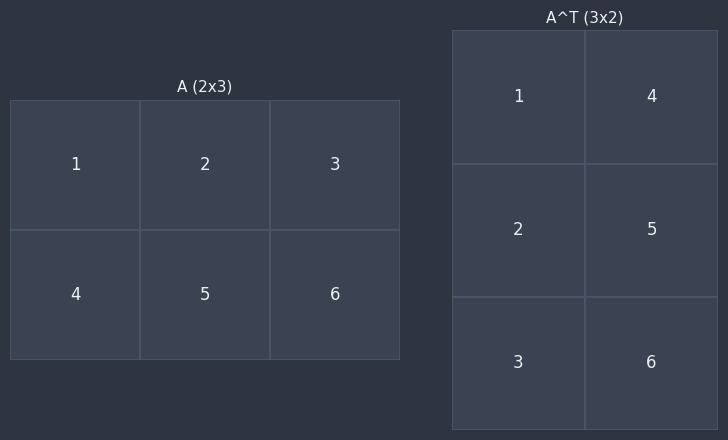

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
desenhar_matriz(ax1, A, titulo="A (2x3)")
desenhar_matriz(ax2, A_transposta, titulo="A^T (3x2)")
plt.tight_layout()
plt.show()

📎 **Conexão:** é exatamente a transposta que usamos para definir simetria e antissimetria no Bloco 3 — A é simétrica quando A = Aᵀ, e antissimétrica quando A = −Aᵀ.

**Pergunta de checagem:** o que acontece se você transpor a transposta de uma matriz, ou seja, calcular (Aᵀ)ᵀ? O resultado é a própria A — por que isso faz sentido, pensando no que "transpor" faz com linhas e colunas?

## 9. Operações elementares sobre linhas

Existem três operações que podem ser aplicadas às linhas de uma matriz sem "perder" a informação essencial que ela carrega:

1. **Trocar duas linhas de posição** (Lᵢ ↔ Lⱼ)
2. **Multiplicar uma linha por um escalar não nulo** (Lᵢ → k·Lᵢ, k ≠ 0)
3. **Somar a uma linha um múltiplo de outra linha** (Lᵢ → Lᵢ + k·Lⱼ)

💡 **Dica:** pense nessas três operações como "regras do jogo" que reorganizam a matriz sem mudar sua essência — mais pra frente, quando falarmos de característica (posto) de uma matriz, isso vai ficar mais preciso. Por ora, o importante é praticar cada uma.

In [38]:
M = np.array([[2, 4, -2], [1, -1, 3], [3, 5, 1]], dtype=float)
print("Matriz original:")
print(M)

# Operação 1: trocar L1 com L2 (indices 0 e 1)
M1 = M.copy()
M1[[0, 1]] = M1[[1, 0]]
print("\nApós trocar L1 <-> L2:")
print(M1)

# Operação 2: multiplicar L1 por 1/2
M2 = M.copy()
M2[0] = M2[0] * (1 / 2)
print("\nApós L1 -> (1/2) L1:")
print(M2)

# Operação 3: somar a L2 o dobro de L1 (L2 -> L2 + 2*L1)
M3 = M.copy()
M3[1] = M3[1] + 2 * M3[0]
print("\nApós L2 -> L2 + 2*L1:")
print(M3)

Matriz original:
[[ 2.  4. -2.]
 [ 1. -1.  3.]
 [ 3.  5.  1.]]

Após trocar L1 <-> L2:
[[ 1. -1.  3.]
 [ 2.  4. -2.]
 [ 3.  5.  1.]]

Após L1 -> (1/2) L1:
[[ 1.  2. -1.]
 [ 1. -1.  3.]
 [ 3.  5.  1.]]

Após L2 -> L2 + 2*L1:
[[ 2.  4. -2.]
 [ 5.  7. -1.]
 [ 3.  5.  1.]]


📎 **Conexão:** essas três operações vão ser a ferramenta central do notebook de Sistemas Lineares — lá, aplicá-las em sequência (um processo chamado escalonamento) permite resolver sistemas de equações inteiros. Aqui, a ideia é só apresentar a ferramenta.

**Pergunta de checagem:** por que a operação "multiplicar uma linha por um escalar" exige que o escalar seja diferente de zero? O que aconteceria com a informação da matriz se fosse permitido multiplicar por 0?

## 10. Matrizes inversíveis

Assim como todo número real diferente de zero tem um inverso multiplicativo (o inverso de 5 é 1/5, porque 5 · 1/5 = 1), algumas matrizes quadradas têm uma **matriz inversa**.

📌 **Definição formal:** uma matriz quadrada A é **inversível** (ou invertível, ou não singular) quando existe uma matriz A⁻¹, de mesma ordem, tal que:

$$A \cdot A^{-1} = A^{-1} \cdot A = I$$

Nem toda matriz quadrada tem inversa — as que não têm são chamadas de **singulares**. O cálculo formal de A⁻¹ (via determinante e matriz adjunta) fica para o próximo notebook, depois de estudarmos determinantes; por aqui, o objetivo é só entender a ideia e verificar se uma matriz dada é inversível.

📎 **Conexão:** queremos saber *calcular* essa inversa na mão? Isso vem no notebook de Determinantes, logo em seguida.

In [39]:
A = np.array([[4, 7], [2, 6]], dtype=float)
A_inv = np.linalg.inv(A)

print("A:")
print(A)
print("A^-1 (calculada pelo numpy):")
print(A_inv)

produto_ida = A @ A_inv
produto_volta = A_inv @ A
print("\nA @ A^-1 (deveria ser a identidade):")
print(np.round(produto_ida, 10))
print(f"\nA @ A^-1 é aproximadamente a identidade? {np.allclose(produto_ida, np.eye(2))}")
print(f"A^-1 @ A tambem é aproximadamente a identidade? {np.allclose(produto_volta, np.eye(2))}")

A:
[[4. 7.]
 [2. 6.]]
A^-1 (calculada pelo numpy):
[[ 0.6 -0.7]
 [-0.2  0.4]]

A @ A^-1 (deveria ser a identidade):
[[ 1. -0.]
 [ 0.  1.]]

A @ A^-1 é aproximadamente a identidade? True
A^-1 @ A tambem é aproximadamente a identidade? True


Nem toda matriz quadrada é inversível — a matriz abaixo tem a segunda linha proporcional à primeira, e isso a torna **singular** (sem inversa):

In [40]:
B = np.array([[2, 4], [1, 2]], dtype=float)  # linhas proporcionais -> singular
try:
    B_inv = np.linalg.inv(B)
    print(B_inv)
except np.linalg.LinAlgError as erro:
    print(f"B não é inversível: {erro}")

B não é inversível: Singular matrix


🎯 **Aplicação prática — cifra de Hill:** a cifra de Hill é um método clássico de criptografia que transforma blocos de letras em números, multiplica por uma matriz-chave para codificar a mensagem, e usa a matriz inversa da chave para decodificar. Sem a matriz inversa, não tem como voltar à mensagem original — um bom fechamento pra essa ideia.

Abaixo, uma versão simplificada da cifra de Hill com um bloco de 2 letras. A "chave" e sua inversa (calculada módulo 26, uma técnica que foge do escopo deste notebook) formam justamente o par A e A⁻¹ que codifica e decodifica a mensagem:

In [41]:
# Cifra de Hill simplificada: cada letra vira um número (A=0, B=1, ..., Z=25)
alfabeto = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"


def texto_para_numeros(texto: str) -> np.ndarray:
    """Converte um texto (sem espaços) em um vetor de numeros, A=0, B=1, ..., Z=25."""
    return np.array([alfabeto.index(letra) for letra in texto])


def numeros_para_texto(numeros: np.ndarray) -> str:
    """Converte um vetor de números de volta em texto, usando o alfabeto A=0,...,Z=25."""
    return "".join(alfabeto[int(n) % 26] for n in numeros)


chave = np.array([[3, 2], [5, 7]])
chave_inversa_mod26 = np.array([[3, 14], [9, 5]])  # inversa de "chave" modulo 26

mensagem = "OI"
vetor_mensagem = texto_para_numeros(mensagem)
vetor_codificado = (chave @ vetor_mensagem) % 26
mensagem_codificada = numeros_para_texto(vetor_codificado)
print(f"Codificando: {mensagem} -> {mensagem_codificada}")

vetor_decodificado = (chave_inversa_mod26 @ vetor_codificado) % 26
mensagem_decodificada = numeros_para_texto(vetor_decodificado)
print(f"Decodificando: {mensagem_codificada} -> {mensagem_decodificada}")

chave_vezes_inversa = (chave @ chave_inversa_mod26) % 26
print(f"\nchave @ chave_inversa_mod26 (mod 26) e a identidade? {np.array_equal(chave_vezes_inversa, np.eye(2, dtype=int))}")

Codificando: OI -> GW
Decodificando: GW -> OI

chave @ chave_inversa_mod26 (mod 26) e a identidade? True


📖 **Leitura complementar:** [Matriz invertível](https://pt.wikipedia.org/wiki/Matriz_invert%C3%ADvel) — verbete em português.

**Pergunta de checagem:** na matriz B do exemplo acima, a segunda linha é exatamente a primeira linha multiplicada por 1/2. Isso faz sentido com B não ter inversa? Que outra matriz "quase igual" a B você consegue imaginar que também seria singular?

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Matriz | tabela de números com m linhas e n colunas; ordem m × n; elemento a_ij na linha i, coluna j |
| Matriz linha / coluna | ordem 1 × n / ordem m × 1 |
| Matriz quadrada | m = n |
| Matriz nula | todos os elementos iguais a 0 |
| Matriz diagonal | quadrada, elementos fora da diagonal principal iguais a 0 |
| Matriz identidade (I) | diagonal, com 1's na diagonal principal; é o "1" da multiplicação |
| Matriz simétrica | A = Aᵀ (só p/ matrizes quadradas) |
| Matriz antissimétrica | A = −Aᵀ, diagonal principal sempre nula (só p/ matrizes quadradas) |
| Igualdade de matrizes | mesma ordem e todos os elementos correspondentes iguais |
| Adição A + B | elemento a elemento, exige mesma ordem de A e B |
| Produto por escalar k·A | multiplica cada elemento por k |
| Produto A·B | exige colunas de A = linhas de B; resultado tem ordem (linhas de A) × (colunas de B); **não é comutativo** |
| Transposta Aᵀ | troca linhas por colunas; (Aᵀ)_ij = a_ji |
| Operações elementares | trocar linhas, multiplicar linha por escalar não nulo, somar múltiplo de uma linha a outra |
| Matriz inversível | existe A⁻¹ tal que A·A⁻¹ = A⁻¹·A = I; nem toda matriz quadrada tem inversa |

## Exercícios

**Básico**
1. Identificar a ordem e os elementos de uma matriz dada, e classificar matrizes especiais.
2. Somar duas matrizes e multiplicar uma matriz por um escalar.

**Intermediário**
3. Multiplicar duas matrizes, verificando antes se a operação é possível.
4. Obter a transposta de uma matriz e verificar se ela é simétrica.

**Desafio**
5. Aplicar uma transformação geométrica (escala) a um conjunto de pontos via produto de matrizes.
6. Verificar se uma matriz dada é a inversa de outra, checando a definição diretamente.

Gabarito completo com resolução comentada em [`0304b_matrizes_gabarito.ipynb`](0304b_matrizes_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: dada a matriz F abaixo, determine em `ordem_ex1` uma
# tupla (linhas, colunas) com a ordem de F, em `elemento_ex1` o valor do
# elemento f_23 (linha 2, coluna 3), e em `classificacao_ex1` uma string
# dizendo se F e uma matriz "quadrada", "diagonal", "nula" ou "nenhuma
# dessas".
F = np.array([[5, 0, 0], [0, -2, 8], [0, 0, 3]])

ordem_ex1 = ...
elemento_ex1 = ...
classificacao_ex1 = ...

print(ordem_ex1, elemento_ex1, classificacao_ex1)

Ellipsis Ellipsis Ellipsis


In [ ]:
# Verificação
assert ordem_ex1 == (3, 3), (
    "Tente de novo, revise: conte o numero de linhas e de colunas de F "
    "(secao 1 - O que e uma Matriz)."
)
assert elemento_ex1 == 8, (
    "Tente de novo, revise: f_23 e o elemento da linha 2, coluna 3 de F "
    "-> em Python, F[1, 2] (secao 1 - O que e uma Matriz)."
)
assert classificacao_ex1 == "quadrada", (
    "Tente de novo, revise: F tem um elemento fora da diagonal principal "
    "diferente de zero (F[1,2] = 8), entao nao e diagonal nem nula "
    "(secao 2 - Matrizes Especiais)."
)
print("Certo!")

AssertionError: Tente de novo, revise: conte o numero de linhas e de colunas de F (secao 1 - O que e uma Matriz).

In [ ]:
# Exercício Básico 2: dadas as matrizes A e B abaixo, calcule em `soma_ex2`
# a soma A + B, e em `triplo_ex2` o resultado de multiplicar A pelo
# escalar 3.
A = np.array([[2, -1], [4, 5]])
B = np.array([[1, 3], [-2, 0]])

soma_ex2 = ...
triplo_ex2 = ...

print(soma_ex2)
print(triplo_ex2)

In [ ]:
# Verificacao
assert np.array_equal(soma_ex2, np.array([[3, 2], [2, 5]])), (
    "Tente de novo, revise: some A e B elemento a elemento "
    "(secao 5 - Adicao de Matrizes)."
)
assert np.array_equal(triplo_ex2, np.array([[6, -3], [12, 15]])), (
    "Tente de novo, revise: multiplique cada elemento de A por 3 "
    "(secao 6 - Produto de Numero por Matriz)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: dadas as matrizes C (ordem 2x3) e D (ordem
# 3x2) abaixo, verifique se o produto C @ D existe (em
# `produto_existe_ex3`, um booleano) e, se existir, calcule-o em
# `produto_ex3`.
C = np.array([[1, 0, 2], [-1, 3, 1]])
D = np.array([[3, 1], [2, 1], [1, 0]])

produto_existe_ex3 = ...
produto_ex3 = ...

print(produto_existe_ex3)
print(produto_ex3)

In [ ]:
# Verificação
assert produto_existe_ex3 is True, (
    "Tente de novo, revise: colunas de C (3) precisam ser iguais as "
    "linhas de D (3) para o produto existir (secao 7 - Produto de "
    "Matrizes)."
)
assert np.array_equal(produto_ex3, np.array([[5, 1], [4, 2]])), (
    "Tente de novo, revise: calcule cada elemento como linha de C vezes "
    "coluna de D (secao 7 - Produto de Matrizes)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: dada a matriz E abaixo, calcule sua
# transposta em `transposta_ex4` e diga em `eh_simetrica_ex4` (booleano)
# se E e uma matriz simetrica.
E = np.array([[4, 7, -1], [7, 2, 5], [-1, 5, 9]])

transposta_ex4 = ...
eh_simetrica_ex4 = ...

print(transposta_ex4)
print(eh_simetrica_ex4)

In [ ]:
# Verificação
assert np.array_equal(transposta_ex4, E.T), (
    "Tente de novo, revise: use E.T ou troque linhas por colunas na mao "
    "(secao 8 - Matriz Transposta)."
)
assert eh_simetrica_ex4 is True, (
    "Tente de novo, revise: compare E com sua transposta elemento a "
    "elemento; E = E^T? (secao 3 - Matriz Simetrica e Antissimetrica)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: a matriz de escala abaixo multiplica a coordenada
# x de um ponto por 2 e a coordenada y por 0.5. Aplique essa
# transformacao ao ponto (4, 6), organizado como uma matriz coluna, e
# guarde o resultado em `ponto_transformado_ex5` (como array de 2
# elementos: [x_novo, y_novo]).
matriz_escala = np.array([[2, 0], [0, 0.5]])
ponto = np.array([[4], [6]])

ponto_transformado_ex5 = ...

print(ponto_transformado_ex5)

In [ ]:
# Verificação
resultado_ex5 = np.ravel(ponto_transformado_ex5)
assert np.allclose(resultado_ex5, [8, 3]), (
    "Tente de novo, revise: calcule matriz_escala @ ponto e depois "
    "achate o resultado num array de 2 elementos (seção 7 - Produto de "
    "Matrizes)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6: a matriz G abaixo e candidata a inversa da matriz
# H. Verifique, calculando H @ G, se G e de fato a inversa de H (isto e,
# se H @ G resulta na matriz identidade). Guarde o resultado booleano em
# `g_eh_inversa_de_h_ex6`.
H = np.array([[2, 5], [1, 3]])
G = np.array([[3, -5], [-1, 2]])

g_eh_inversa_de_h_ex6 = ...

print(g_eh_inversa_de_h_ex6)

In [ ]:
# Verificação
assert g_eh_inversa_de_h_ex6 is True, (
    "Tente de novo, revise: calcule H @ G e compare com a matriz "
    "identidade 2x2 usando np.allclose (secao 10 - Matrizes Inversíveis)."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`00_introducao_python.ipynb`](../00_fundamentos_e_python/00_introducao_python.ipynb) (variáveis, listas, laços e funções)
- [`0105a_funcoes.ipynb`](../01_conjuntos_e_funcoes/0105a_funcoes.ipynb) (noção de função, útil para pensar numa matriz como função de pares (i,j))
- [`0303a_progressao_geometrica.ipynb`](0303a_progressao_geometrica.ipynb) (fecha o bloco de sequências/progressões antes de entrar em matrizes)

**Isso será usado em:**
- 📌 Determinantes (retoma matrizes quadradas e fecha o cálculo da inversa)
- 📌 Sistemas Lineares (usa diretamente as operações elementares sobre linhas para escalonamento)